In [2]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid",context ="notebook")
plt.rcParams["figure.figsize"]=(7,4)
plt.rcParams["figure.dpi"] = 110


print(f"python: {sys.version.split()[0]}")
print(f"Platform:{platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.13.15
Platform:Linux-6.6.122+-x86_64-with-glibc2.39
seaborn: 0.13.2
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1


In [3]:
df = pd.read_csv("/content/SeoulBikeData.csv", encoding="cp1252")
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
print(df.sample(10,random_state=1))

            Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
4136  22/05/2018                694     8             18.2           63   
6705  06/09/2018               1186     9             23.5           72   
3538  27/04/2018                789    10             15.3           50   
6583  01/09/2018                511     7             21.1           81   
1993  22/02/2018                190     1             -2.2           58   
6751  08/09/2018                511     7             16.0           70   
6483  28/08/2018                281     3             22.9           93   
6951  16/09/2018                222    15             23.2           83   
4406  02/06/2018               1396    14             29.8           23   
2021  23/02/2018                 39     5              1.0           91   

      Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
4136               0.8              1731                       11.0   
6705               0.5          

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [6]:
sayisal_sutunlar = df.select_dtypes(include=[np.number])
sayisal_sutunlar

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0
8756,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0
8757,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0
8758,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0


In [7]:
X_reg= sayisal_sutunlar.drop("Rented Bike Count",axis=1)
y_reg=sayisal_sutunlar["Rented Bike Count"]

In [8]:
X_reg

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
0,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0
1,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0
2,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0
3,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0
4,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
8755,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0
8756,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0
8757,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0
8758,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0


In [9]:
y_reg

,Rented Bike Count
0,254
1,204
2,173
3,107
4,78
...,...
8755,1003
8756,764
8757,694
8758,712


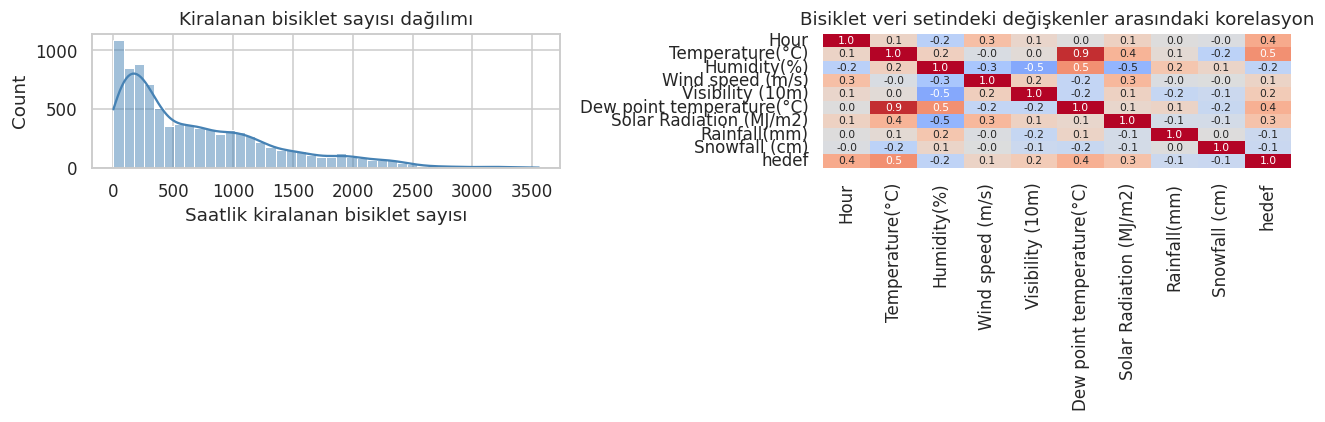

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(y_reg, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Kiralanan bisiklet sayısı dağılımı")
axes[0].set_xlabel("Saatlik kiralanan bisiklet sayısı")

corr = pd.concat([X_reg, y_reg.rename("hedef")], axis=1).corr()
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            ax=axes[1], cbar=False, annot_kws={"size": 7})
axes[1].set_title("Bisiklet veri setindeki değişkenler arasındaki korelasyon")

plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
Xr_train,Xr_test,yr_train,yr_test=train_test_split(X_reg,y_reg,test_size=0.2,random_state=SEED)

In [12]:
print(f"{Xr_train.shape[0]}")
Xr_test.shape[0]

7008


1752

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
baseline = DummyRegressor(strategy="mean").fit(Xr_train,yr_train)

linear = LinearRegression().fit(Xr_train,yr_train)

def regresyon_raporu (model,X, y,ad):
  tahmin=model.predict(X)
  return{
     "Model" :ad,
     "Mae"   : mean_absolute_error(y,tahmin),
     "mse"   : mean_squared_error(y,tahmin),
     "rmse"  : np.sqrt(mean_squared_error(y,tahmin)),
     "r2"    : r2_score(y,tahmin)
    }
sonuc = pd.DataFrame([
    regresyon_raporu(baseline,Xr_train,yr_train,"Baseline"),
    regresyon_raporu(linear,Xr_test,yr_test,"Linear")
]).set_index("Model").round(3)
sonuc


,Mae,mse,rmse,r2
Model,,,,
Baseline,519.91,415806.106,644.830,0.000
Linear,349.28,222880.723,472.102,0.465


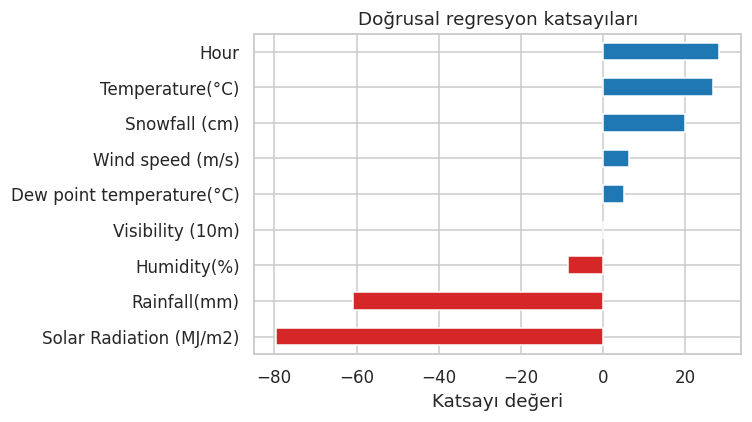

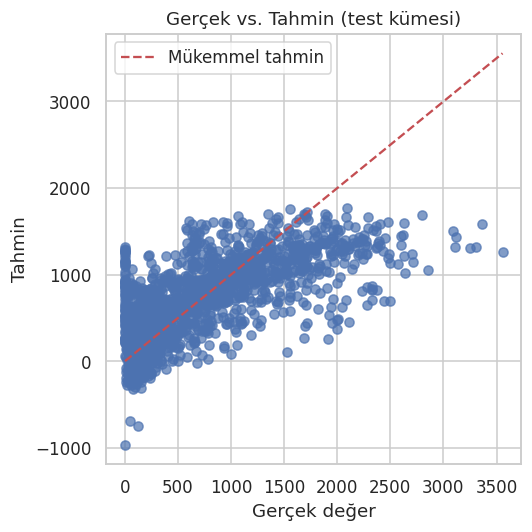

In [14]:
katsayilar = pd.Series(linear.coef_, index=X_reg.columns).sort_values()

plt.figure(figsize=(7, 4))
katsayilar.plot(kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red"))
plt.title("Doğrusal regresyon katsayıları")
plt.xlabel("Katsayı değeri")
plt.tight_layout()
plt.show()


tahmin = linear.predict(Xr_test)
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, tahmin, alpha=0.7)
lim = [yr_test.min(), yr_test.max()]
plt.plot(lim, lim, "r--", label="Mükemmel tahmin")
plt.xlabel("Gerçek değer")
plt.ylabel("Tahmin")
plt.title("Gerçek vs. Tahmin (test kümesi)")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
from sklearn.linear_model import Ridge,Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modeller= {
    "Doğrusal": make_pipeline(StandardScaler(),LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(),Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(),Lasso(alpha=1.0))
}

satirlar =[]

for ad,m in modeller.items():
  m.fit(Xr_train,yr_train)
  satirlar.append(regresyon_raporu(m,Xr_test,yr_test,ad))

pd.DataFrame(satirlar).set_index("Model").round(3)

,Mae,mse,rmse,r2
Model,,,,
Doğrusal,349.280,222880.723,472.102,0.465
Ridge,349.269,222880.303,472.102,0.465
Lasso,349.324,222933.018,472.158,0.465


In [16]:
lasso= modeller["Lasso"].named_steps["lasso"]
pd.Series(lasso.coef_,index=X_reg.columns).round(2).to_frame("Lasso değişkenler").T

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
Lasso değişkenler,194.64,360.9,-148.46,4.76,15.34,11.11,-67.09,-64.65,6.82


In [17]:
print(modeller.keys())

dict_keys(['Doğrusal', 'Ridge', 'Lasso'])


In [18]:
df["Functioning Day"] = df["Functioning Day"].map({"Yes": 1, "No": 0})

X_clf = df.select_dtypes(include="number").drop(["Functioning Day"], axis=1)
y_clf = df["Functioning Day"]
X_clf.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0


In [19]:
Xc_train,Xc_test,yc_train,yc_test=train_test_split(X_clf,y_clf,test_size=0.2,random_state=SEED)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent").fit(Xc_train,yc_train),
    "Logistic": LogisticRegression().fit(Xc_train,yc_train),
    "KNN": KNeighborsClassifier().fit(Xc_train,yc_train),
    "Karar ağacı": DecisionTreeClassifier().fit(Xc_train,yc_train),
    "Rastgele orman": RandomForestClassifier().fit(Xc_train,yc_train)
}


satirlar =[]

for ad,m in siniflandiricilar.items():
  m.fit(Xc_train,yc_train)
  satirlar.append(
      {
          "Model": ad,
          "Eğitim" : accuracy_score(yc_train,m.predict(Xc_train)),
          "Test": accuracy_score(yc_test,m.predict(Xc_test))
      }
  )

pd.DataFrame(satirlar).set_index("Model").round(3)

,Eğitim,Test
Model,,
Baseline,0.966,0.967
Logistic,1.000,0.999
KNN,0.998,0.995
Karar ağacı,1.000,1.000
Rastgele orman,1.000,1.000


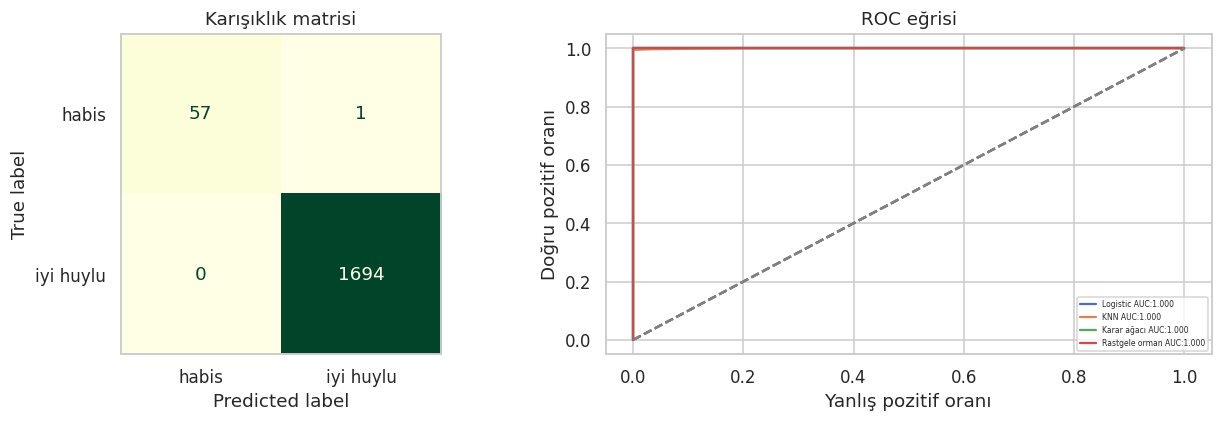

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay ,classification_report, roc_curve, roc_auc_score

model = siniflandiricilar["Logistic"]
tahmin = model.predict(Xc_test)
olasilik = model.predict_proba(Xc_test)[:,1]

fig ,axes = plt.subplots(1,2,figsize=(12,4))

cm = confusion_matrix(yc_test,tahmin)
ConfusionMatrixDisplay.from_predictions(yc_test,tahmin, display_labels =["habis","iyi huylu"], cmap="YlGn",ax=axes[0],colorbar=False)
axes[0].set_title("Karışıklık matrisi")
axes[0].grid(False)


for ad in ["Logistic","KNN","Karar ağacı","Rastgele orman"]:
  p=siniflandiricilar[ad].predict_proba(Xc_test)[:,1]
  fpr,tpr,_=roc_curve(yc_test,p)
  axes[1].plot(fpr,tpr,label=f"{ad} AUC:{roc_auc_score(yc_test,p):.3f}")
  axes[1].plot([0,1],[0,1],linestyle="--",color="gray")
  axes[1].set_xlabel("Yanlış pozitif oranı")
  axes[1].set_ylabel("Doğru pozitif oranı")
  axes[1].set_title("ROC eğrisi")
  axes[1].legend(fontsize=5)
  axes[1].grid(True)

plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import StratifiedKFold,cross_val_score


cv = StratifiedKFold(n_splits=5, shuffle =True, random_state=SEED)

satirlar =[]

for ad, m in siniflandiricilar.items():
  skorlar=cross_val_score(m,Xc_train,yc_train,cv=cv,scoring="accuracy")
  satirlar.append({"Model":ad,"Ortalama skor":skorlar.mean(),"Standart sapma":skorlar.std()})

cv_sonuc= pd.DataFrame(satirlar).set_index("Model").sort_values("Ortalama skor",ascending=False).round(3)
display(cv_sonuc)

,Ortalama skor,Standart sapma
Model,,
Rastgele orman,1.000,0.000
Karar ağacı,1.000,0.000
Logistic,1.000,0.001
KNN,0.995,0.002
Baseline,0.966,0.000


In [23]:

from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(StandardScaler(),KNeighborsClassifier())

param_grid = {
    "kneighborsclassifier__n_neighbors":[1,3,5,7,9,11,15,21],
    "kneighborsclassifier__weights":["uniform","distance"]
}

opt =GridSearchCV(pipe,param_grid,cv=cv,scoring="accuracy",n_jobs=-1)
opt.fit(Xc_train,yc_train)

print("best parametre:", opt.best_params_)
print(f"en iyi cv:{opt.best_score_:3f}")

best parametre: {'kneighborsclassifier__n_neighbors': 3, 'kneighborsclassifier__weights': 'distance'}
en iyi cv:0.992722


In [24]:

scaler_yanlis= StandardScaler().fit(X_clf)
Xc_tr= scaler_yanlis.transform(Xc_train)
Xc_te= scaler_yanlis.transform(Xc_test)


scaler_dogru = StandardScaler().fit(Xc_train)
Xc_tr= scaler_dogru.transform(Xc_train)
Xc_te= scaler_dogru.transform(Xc_test)


print("yanlış yöntem " ,scaler_yanlis.mean_[:3].round(2))
print("doğru yöntem" ,scaler_dogru.mean_[:3].round(2))

yanlış yöntem  [704.6   11.5   12.88]
doğru yöntem [704.77  11.51  12.93]


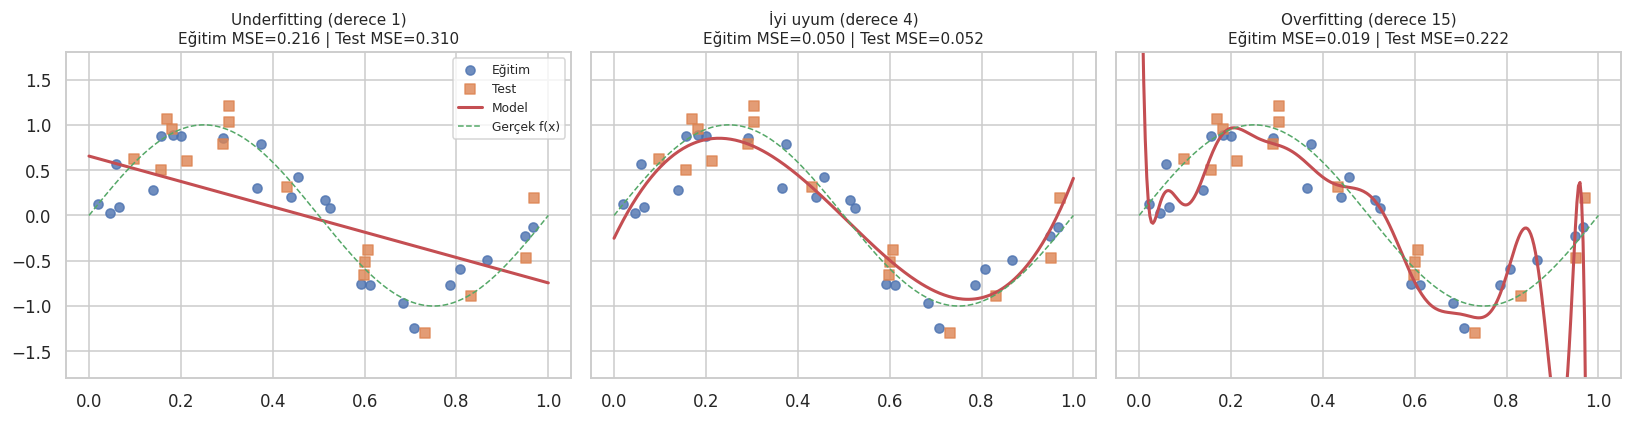

In [25]:
from sklearn.preprocessing import PolynomialFeatures

rng = np.random.RandomState(SEED)
n = 40
x = np.sort(rng.uniform(0, 1, n))
y = np.sin(2 * np.pi * x) + rng.normal(0, 0.25, n)  # gerçek fonksiyon + gürültü

x_tr, x_te, y_tr, y_te = train_test_split(x.reshape(-1, 1), y, test_size=0.4, random_state=SEED)

xs = np.linspace(0, 1, 300).reshape(-1, 1)
dereceler = [1, 4, 15]
basliklar = ["Underfitting (derece 1)", "İyi uyum (derece 4)", "Overfitting (derece 15)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, d, b in zip(axes, dereceler, basliklar):
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(x_tr, y_tr)
    tr_hata = mean_squared_error(y_tr, model.predict(x_tr))
    te_hata = mean_squared_error(y_te, model.predict(x_te))
    ax.scatter(x_tr, y_tr, label="Eğitim", alpha=0.8)
    ax.scatter(x_te, y_te, label="Test", alpha=0.8, marker="s")
    ax.plot(xs, model.predict(xs), "r-", lw=2, label="Model")
    ax.plot(xs, np.sin(2 * np.pi * xs), "g--", lw=1, label="Gerçek f(x)")
    ax.set_ylim(-1.8, 1.8)
    ax.set_title(f"{b}\nEğitim MSE={tr_hata:.3f} | Test MSE={te_hata:.3f}", fontsize=10)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

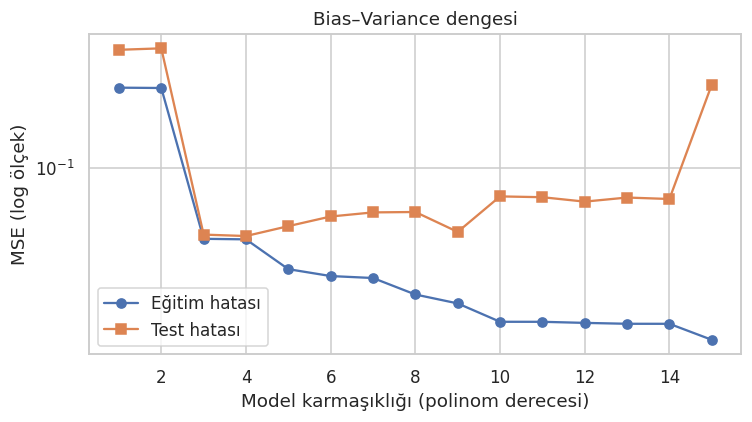

Test hatasının en düşük olduğu derece: 4


In [26]:
# Model karmaşıklığı arttıkça eğitim ve test hatası nasıl değişir?
derece_araligi = range(1, 16)
egitim_hatalari, test_hatalari = [], []

for d in derece_araligi:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(x_tr, y_tr)
    egitim_hatalari.append(mean_squared_error(y_tr, model.predict(x_tr)))
    test_hatalari.append(mean_squared_error(y_te, model.predict(x_te)))

plt.figure(figsize=(7, 4))
plt.plot(derece_araligi, egitim_hatalari, "o-", label="Eğitim hatası")
plt.plot(derece_araligi, test_hatalari, "s-", label="Test hatası")
plt.yscale("log")
plt.xlabel("Model karmaşıklığı (polinom derecesi)")
plt.ylabel("MSE (log ölçek)")
plt.title("Bias–Variance dengesi")
plt.legend()
plt.tight_layout()
plt.show()

en_iyi = list(derece_araligi)[int(np.argmin(test_hatalari))]
print(f"Test hatasının en düşük olduğu derece: {en_iyi}")

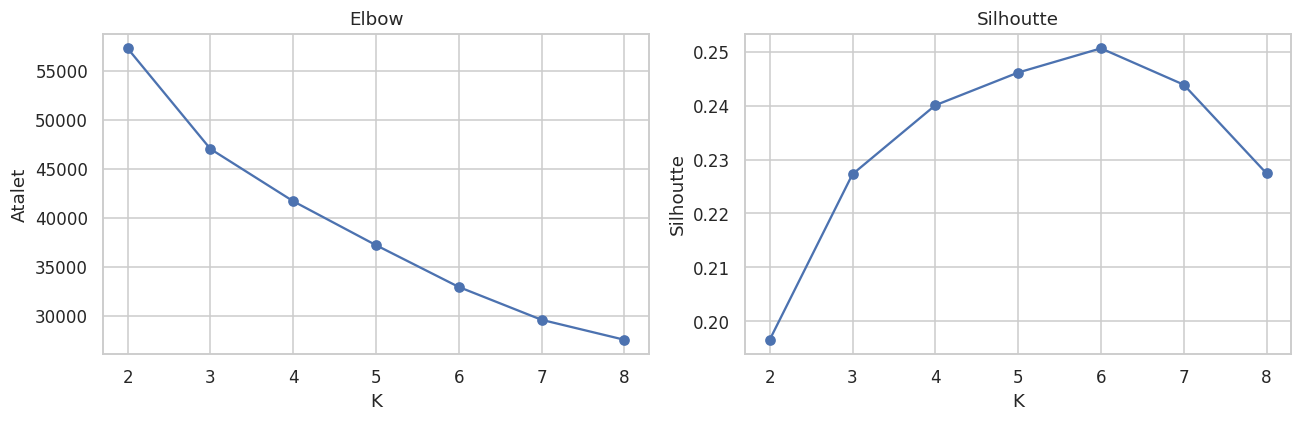

In [27]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

k_degerleri = range(2,9)
atalet, silhoutte= [],[]

for k in k_degerleri:
  km=KMeans(n_clusters=k, n_init=10,random_state=SEED).fit(Xc_tr)
  atalet.append(km.inertia_)
  silhoutte.append(silhouette_score(Xc_tr,km.labels_))


fig, axes =plt.subplots(1,2,figsize=(12,4))

axes[0].plot(k_degerleri,atalet,marker="o")
axes[0].set_title("Elbow")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Atalet")

axes[1].plot(k_degerleri,silhoutte,marker="o")
axes[1].set_title("Silhoutte")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhoutte")

plt.tight_layout()
plt.show()